# Exploratory Data Analysis – Kenya Food Prices

## 1.Objective

This notebook explores Kenya's historical food price data to understand
price patterns across commodities, markets, regions, time, and other
relevant factors.

The analysis focuses on identifying data quality issues, distributions,
temporal patterns, regional differences, price volatility, and potential
relationships between rainfall and food prices.

The findings will help inform the development of food price forecasting
and market intelligence models.

In [13]:
# Import libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [14]:
# Load the cleaned dataset
df = pd.read_csv("../../data/cleaned/wfp_with_rainfall.csv")

# Display the first five records
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22,2006-01-01,17.813333
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58,2006-01-01,17.813333
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47,2006-01-01,17.813333
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15,2006-01-01,17.813333
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24,2006-01-01,44.527500


## 3. Dataset Overview

We first examine the size of the dataset to understand how many
observations and variables are available for analysis.

In [15]:
# Check the number of rows and columns
df.shape

(27316, 18)

In [16]:
# Display all column names
df.columns.tolist()

['date',
 'admin1',
 'admin2',
 'market',
 'market_id',
 'latitude',
 'longitude',
 'category',
 'commodity',
 'commodity_id',
 'unit',
 'priceflag',
 'pricetype',
 'currency',
 'price',
 'usdprice',
 'date_month',
 'rainfall_mm']

## 4. Data Types and Structure

Understanding the data types helps identify which variables are
categorical, numerical, or date-related and determines how they should
be handled during analysis.

In [17]:
# Examine column names, data types, and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27316 entries, 0 to 27315
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          27316 non-null  str    
 1   admin1        27316 non-null  str    
 2   admin2        27316 non-null  str    
 3   market        27316 non-null  str    
 4   market_id     27316 non-null  int64  
 5   latitude      27316 non-null  float64
 6   longitude     27316 non-null  float64
 7   category      27316 non-null  str    
 8   commodity     27316 non-null  str    
 9   commodity_id  27316 non-null  int64  
 10  unit          27316 non-null  str    
 11  priceflag     27316 non-null  str    
 12  pricetype     27316 non-null  str    
 13  currency      27316 non-null  str    
 14  price         27316 non-null  float64
 15  usdprice      27316 non-null  float64
 16  date_month    27316 non-null  str    
 17  rainfall_mm   25829 non-null  float64
dtypes: float64(5), int64(2), str(11)
memo

## 5. Missing Values

We check for missing values because incomplete observations can affect
statistical analysis and machine learning models.

In [18]:
# Count missing values in each column
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

rainfall_mm    1487
dtype: int64

rainfall_mm contains missing observations, while the other variables are complete. Rainfall-related analysis will therefore use observations where rainfall data are available.

## 6. Duplicate Records

We check for duplicate rows to determine whether the dataset contains
repeated observations.

In [19]:
# Count completely duplicated rows
df.duplicated().sum()

np.int64(0)

### Finding

The dataset contains **0 duplicate records**, indicating that there are no completely repeated rows. Therefore, no duplicate records need to be removed at this stage.

## 7. Date Coverage

The dataset covers more than 20 years of observations. Examining the
date range is important because the project aims to understand
historical price patterns and support future price forecasting.

In [20]:
# Convert date columns to datetime format
df['date'] = pd.to_datetime(df['date'])
df['date_month'] = pd.to_datetime(df['date_month'])

# Display the date range
print("Start date:", df['date'].min())
print("End date:", df['date'].max())

Start date: 2006-01-15 00:00:00
End date: 2026-08-15 00:00:00


### Finding

The dataset covers food price observations from **15 January 2006 to 15 August 2026**. This long historical period provides a strong basis for examining long-term trends, seasonal patterns, price volatility, and changes across markets and commodities.

## 8. Categorical Variables

We examine the number of unique markets, regions, commodities, and
food categories to understand the geographical and product coverage
of the dataset.

In [21]:
# Count unique values for important categorical variables
print("Number of markets:", df['market'].nunique())
print("Number of regions:", df['admin1'].nunique())
print("Number of commodities:", df['commodity'].nunique())
print("Number of categories:", df['category'].nunique())

Number of markets: 225
Number of regions: 7
Number of commodities: 51
Number of categories: 8


In [29]:
# Show observations by region
df['admin1'].value_counts()

admin1
Rift Valley      12126
North Eastern     4427
Nairobi           3677
Eastern           3227
Coast             2383
Nyanza            1216
Central            260
Name: count, dtype: int64

In [30]:
# Show the 15 most frequently recorded commodities
df['commodity'].value_counts().head(15)

commodity
Beans (dry)                1806
Maize (white)              1633
Maize                      1518
Sugar                      1418
Wheat flour                1373
Beans                      1327
Salt                       1287
Potatoes (Irish)           1275
Sorghum                    1012
Rice (aromatic)             969
Maize (white, dry)          963
Oil (vegetable)             926
Kale                        825
Milk (cow, pasteurized)     817
Rice                        746
Name: count, dtype: int64

### Finding

The dataset covers **7 regions, 225 markets, 51 commodities, and 8 food categories**.

Rift Valley has the largest number of observations (12,126), followed by North Eastern (4,427) and Nairobi (3,677). Central has the fewest observations (260), showing that the distribution of observations is uneven across regions.

At the commodity level, Beans (dry), Maize (white), and Maize have the highest number of observations. This provides substantial historical data for analyzing these commodities.

## 9. Commodity Distribution

We examine how frequently each commodity appears in the dataset.
This helps identify commodities with sufficient historical observations
for more detailed analysis and potential forecasting.

In [31]:
# Count observations for each commodity
commodity_counts = df['commodity'].value_counts()

# Display the 15 most frequently observed commodities
commodity_counts.head(15)

commodity
Beans (dry)                1806
Maize (white)              1633
Maize                      1518
Sugar                      1418
Wheat flour                1373
Beans                      1327
Salt                       1287
Potatoes (Irish)           1275
Sorghum                    1012
Rice (aromatic)             969
Maize (white, dry)          963
Oil (vegetable)             926
Kale                        825
Milk (cow, pasteurized)     817
Rice                        746
Name: count, dtype: int64

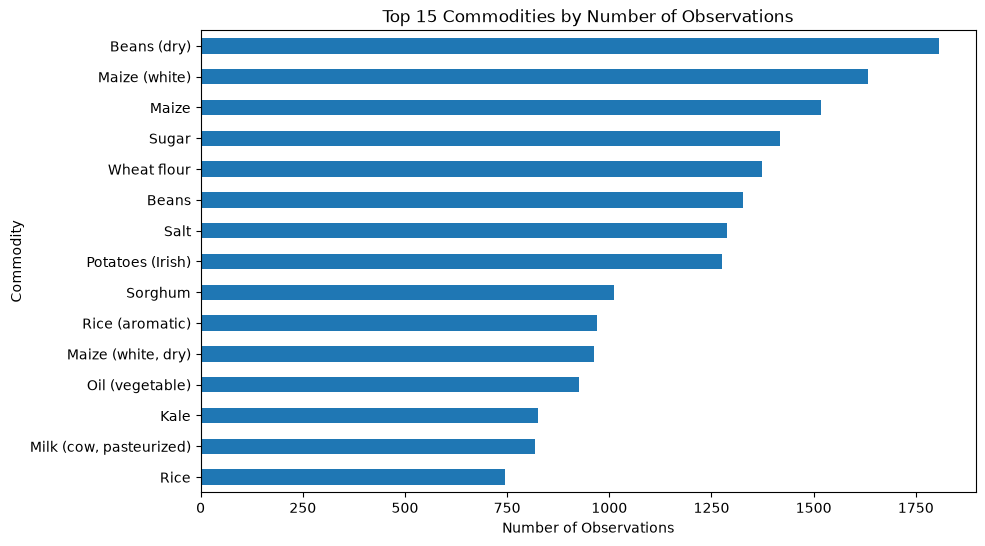

In [25]:
# Plot the 15 most frequently observed commodities
plt.figure(figsize=(10, 6))

commodity_counts.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Commodities by Number of Observations')
plt.xlabel('Number of Observations')
plt.ylabel('Commodity')

plt.show()

### Observation

The dataset contains observations for multiple food commodities, with
some commodities having substantially more records than others.
Commodities with longer and more consistent historical records may be
more suitable for detailed time-series analysis and forecasting.

## 10. Price Units

Food commodities are reported using different measurement units such as
KG, 90 KG, litres, and grams. This is important because raw prices
cannot always be compared directly when the units differ.

In [26]:
# Examine the measurement units used in the dataset
df['unit'].value_counts()

unit
KG        14380
90 KG      4060
L          2611
50 KG      1912
200 G      1287
500 ML      814
Unit        589
64 KG       518
13 KG       469
126 KG      450
400 G       178
Head         26
Bunch        22
Name: count, dtype: int64

In [27]:
# Examine the different price types
df['pricetype'].value_counts()

pricetype
Retail       18218
Wholesale     9098
Name: count, dtype: int64

The dataset contains multiple measurement units and both retail and
wholesale prices. Therefore, direct comparison of raw prices across all
commodities may be misleading.

Further price comparisons should account for the measurement unit and
price type.

In [32]:
# Calculate the percentage distribution of price types
price_type_pct = df['pricetype'].value_counts(normalize=True) * 100

price_type_pct.round(2)

pricetype
Retail       66.69
Wholesale    33.31
Name: proportion, dtype: float64

### Price Type Distribution

Approximately two-thirds of the observations are retail prices, while
one-third are wholesale prices. This imbalance should be considered
when comparing retail and wholesale price patterns.

## 11. Descriptive Statistics

We use descriptive statistics to understand the central tendency,
spread, and range of the numerical variables.

In [33]:
# Summary statistics for numerical variables
df[['price', 'usdprice', 'rainfall_mm']].describe()

,price,usdprice,rainfall_mm
count,27316.000000,27316.000000,25829.000000
mean,1317.337703,12.017051,82.021631
std,2593.837126,23.019250,75.144244
min,5.000000,0.039000,0.090000
25%,70.000000,0.610000,22.320000
50%,130.000000,1.030000,60.260000
75%,1027.000000,9.445000,115.502857
max,19800.000000,184.820000,483.984000


### Observation

The `price` variable has a mean of approximately 1,317 KES and a median of 130 KES. The large difference between the mean and median, together with a standard deviation of approximately 2,594 KES, indicates substantial variation in recorded prices.

The `usdprice` variable shows a similar pattern, with a mean of 12.02 USD and a median of 1.03 USD.

For `rainfall_mm`, the mean is approximately 82.02 mm and the median is 60.26 mm, indicating variation in rainfall levels across the observations.

The large ranges observed in the price variables suggest that further investigation of price distributions and potential outliers is necessary.

## 12. Price Distribution

We visualize the distribution of recorded food prices to understand their
spread, concentration, and potential extreme values. This is important
because the descriptive statistics indicate a substantial difference
between the mean and median price.

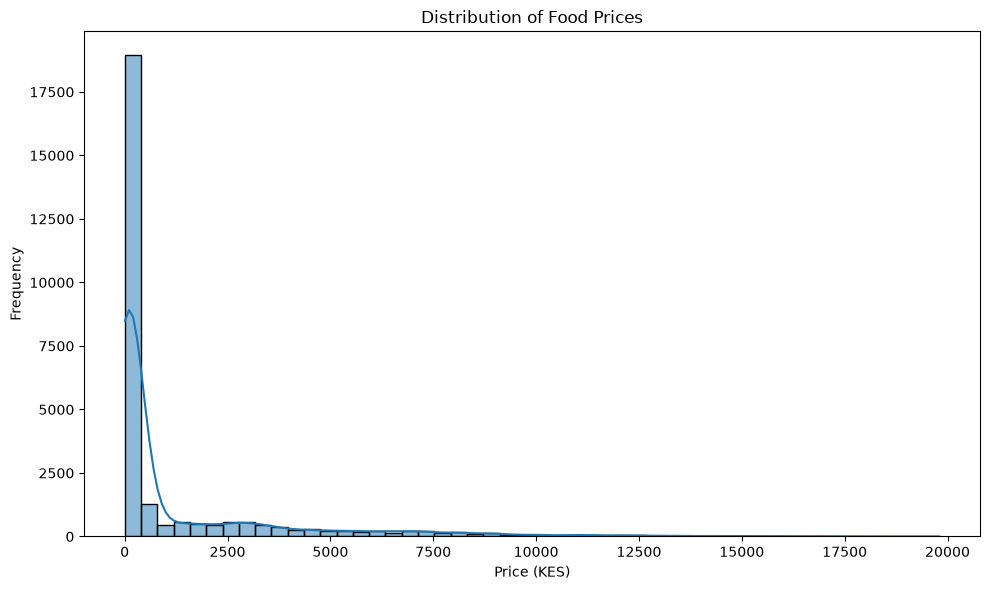

In [34]:
# Plot the distribution of food prices
plt.figure(figsize=(10, 6))

sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Food Prices')
plt.xlabel('Price (KES)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

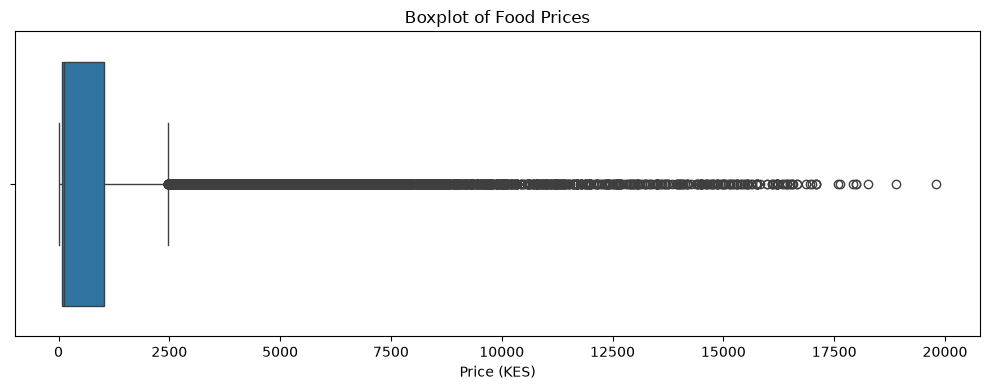

In [35]:
# Visualize potential extreme price values
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['price'])

plt.title('Boxplot of Food Prices')
plt.xlabel('Price (KES)')

plt.tight_layout()
plt.show()

### Observation

The food price distribution is strongly right-skewed, with most observations concentrated at relatively low prices and a smaller number of observations having substantially higher values.

The boxplot also identifies many potential high-price outliers. These values should not automatically be treated as errors because the dataset contains different commodities, measurement units, and price types. Further analysis is therefore required before deciding how to handle extreme values.

## 13. Investigating High Price Values

The previous analysis showed a large number of potential high-price
observations. We examine the commodities associated with the highest
recorded prices to determine whether these values are concentrated in
specific products or measurement units.

In [36]:
# Display the 20 observations with the highest prices
df[['date', 'admin1', 'market', 'commodity', 'unit',
    'pricetype', 'price']].sort_values(
    by='price', ascending=False
).head(20)

,date,admin1,market,commodity,unit,pricetype,price
7130,2021-05-15,Rift Valley,Lomut (West Pokot),Beans (rosecoco),90 KG,Wholesale,19800.0
10296,2023-06-15,North Eastern,Takaba (Mandera),Beans (yellow),90 KG,Wholesale,18900.0
9488,2022-10-15,North Eastern,Garissa town (Garissa),Beans (yellow),90 KG,Wholesale,18252.0
9850,2023-01-15,Rift Valley,Eldoret town (Uasin Gishu),Cowpeas,90 KG,Wholesale,18000.0
10332,2023-06-15,Rift Valley,Eldoret town (Uasin Gishu),Beans (yellow),90 KG,Wholesale,18000.0
10434,2023-07-15,Rift Valley,Eldoret town (Uasin Gishu),Beans (yellow),90 KG,Wholesale,17925.0
10241,2023-05-15,Rift Valley,Eldoret town (Uasin Gishu),Beans (yellow),90 KG,Wholesale,17640.0
10205,2023-05-15,North Eastern,Garissa town (Garissa),Beans (yellow),90 KG,Wholesale,17586.0
9051,2022-07-15,Eastern,Kaanwa (Tharaka Nithi),Beans (dolichos),90 KG,Wholesale,17100.0
10388,2023-07-15,Nairobi,Wakulima (Nairobi),Beans (yellow),90 KG,Wholesale,17100.0


### Observation

The highest recorded prices are mainly associated with pulses such as
beans and cowpeas. Most of these observations use a 90 KG measurement
unit and are wholesale prices.

For example, the highest recorded price is 19,800 KES for 90 KG of
Beans (rosecoco) in Lomut, West Pokot in May 2021.

This indicates that the extreme values identified in the overall price
distribution are not necessarily data errors. Differences in commodity,
measurement unit, and price type contribute to the observed variation.
Therefore, extreme values should be investigated within comparable
commodity and unit groups rather than removed automatically.

## 14. Food Price Trend Over Time

Since the project aims to forecast future food prices, we examine how
prices have changed over the historical period. This helps identify
long-term trends and periods of substantial price movement.

In [38]:
# Calculate average monthly food price
monthly_price = (
    df.groupby('date_month')['price']
      .mean()
      .reset_index()
)

monthly_price.head()


,date_month,price
0,2006-01-01,941.543929
1,2006-02-01,1005.952188
2,2006-03-01,1042.115161
3,2006-04-01,1096.978437
4,2006-05-01,1077.952500


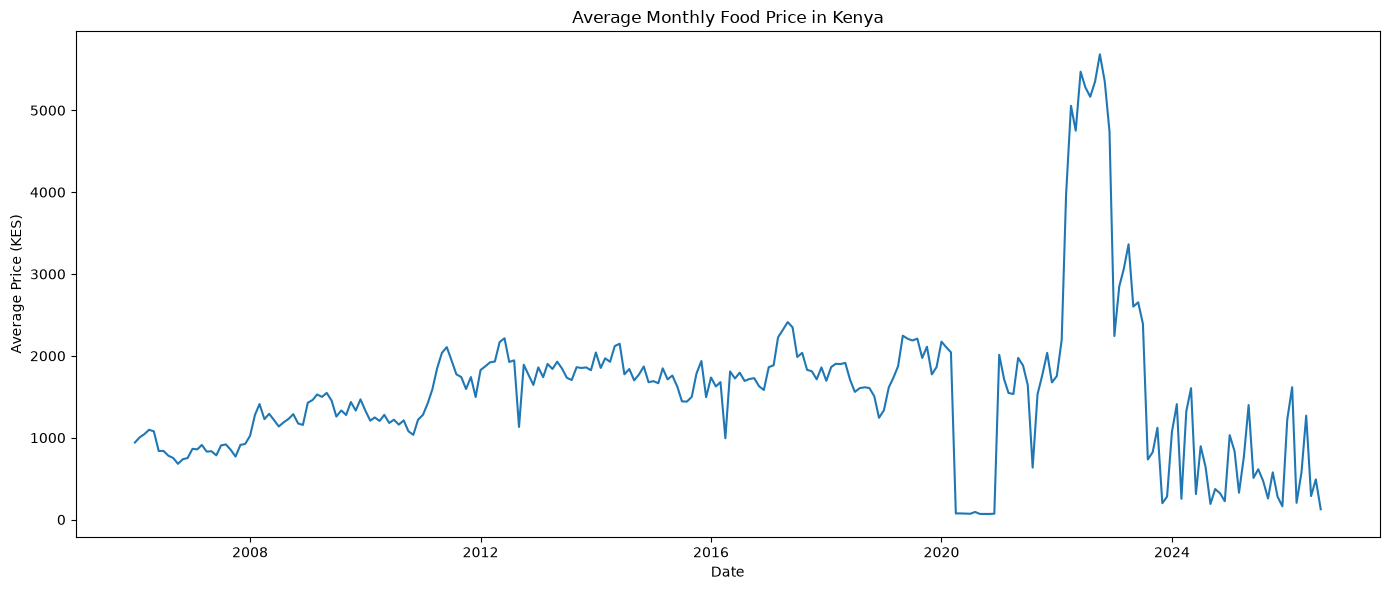

In [39]:
# Plot average monthly food price over time
plt.figure(figsize=(14, 6))

plt.plot(monthly_price['date_month'], monthly_price['price'])

plt.title('Average Monthly Food Price in Kenya')
plt.xlabel('Date')
plt.ylabel('Average Price (KES)')

plt.tight_layout()
plt.show()

### Observation

The monthly average price shows substantial variation over the study
period, including a pronounced increase around 2022–2023 and periods of
very low average values around 2020 and after 2023.

However, this aggregate trend combines different commodities,
measurement units, markets, and price types. Therefore, the observed
changes cannot be interpreted as a direct measure of the price movement
of a particular food commodity.

Commodity-specific analysis will provide a more meaningful basis for
understanding price trends and forecasting.

In [44]:
# Create a year column
df['year'] = df['date'].dt.year

# Compare units across the three years
pd.crosstab(
    df[df['year'].isin([2019, 2020, 2021])]['year'],
    df[df['year'].isin([2019, 2020, 2021])]['unit']
)

unit,126 KG,13 KG,200 G,400 G,50 KG,500 ML,64 KG,90 KG,Bunch,Head,KG,L,Unit
year,,,,,,,,,,,,,
2019,0,0,1,12,51,12,0,166,0,0,229,49,1
2020,0,0,0,12,12,12,0,35,1,0,179,48,1
2021,162,170,264,0,447,258,172,921,21,26,2672,348,256


In [45]:
# Count observations per month
monthly_count = (
    df.groupby('date_month')
      .size()
      .reset_index(name='observations')
)

# Examine 2019–2021
monthly_count[
    (monthly_count['date_month'] >= '2019-01-01') &
    (monthly_count['date_month'] <= '2021-12-01')
]

,date_month,observations
156,2019-01-01,54
157,2019-02-01,44
158,2019-03-01,44
159,2019-04-01,46
160,2019-05-01,47
161,2019-06-01,44
162,2019-07-01,47
163,2019-08-01,44
164,2019-09-01,42
165,2019-10-01,42


## 15. Unit Composition Over Time

The dataset contains food prices reported using different measurement units.

We examine how the distribution of these units changes across years to
understand whether changes in data coverage or measurement units may influence
observed price trends.

This is important because prices recorded using different units are not
directly comparable.

In [84]:
## Unit Composition Over Time

df['year'] = df['date'].dt.year

unit_by_year = pd.crosstab(df['year'], df['unit'])

unit_by_year

unit,126 KG,13 KG,200 G,400 G,50 KG,500 ML,64 KG,90 KG,Bunch,Head,KG,L,Unit
year,,,,,,,,,,,,,
2006,0,0,0,12,29,12,0,128,0,0,149,12,0
2007,0,0,0,12,38,12,0,127,0,0,147,12,0
2008,0,0,0,12,43,12,0,134,0,0,157,12,0
2009,0,0,0,12,41,12,0,136,0,0,167,12,0
2010,0,0,0,12,43,12,0,134,0,0,172,12,0
2011,0,0,0,12,43,12,0,136,0,0,166,12,0
2012,0,0,0,12,43,12,0,134,0,0,154,12,0
2013,0,0,0,12,39,11,0,135,0,0,160,12,0
2014,0,0,0,12,41,11,0,139,0,0,164,18,0


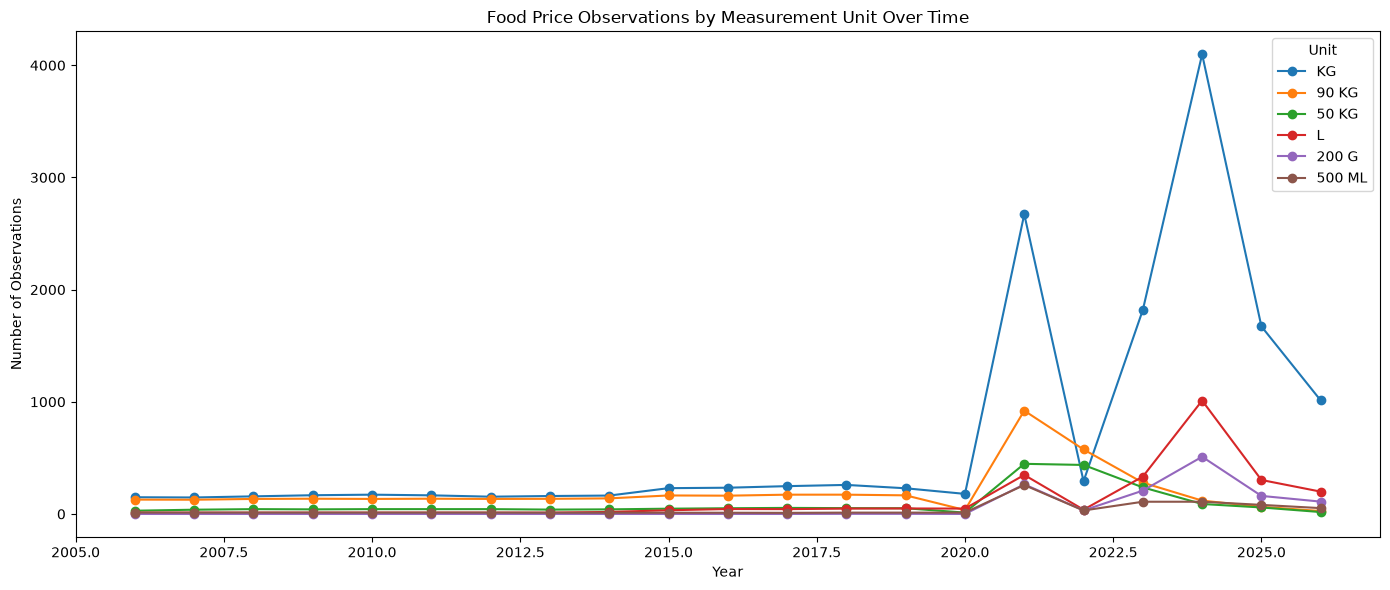

In [49]:
# Plot the main measurement units over time
main_units = ['KG', '90 KG', '50 KG', 'L', '200 G', '500 ML']

unit_by_year[main_units].plot(
    figsize=(14, 6),
    marker='o'
)

plt.title('Food Price Observations by Measurement Unit Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.legend(title='Unit')
plt.tight_layout()
plt.show()

investigated the measurement units because the dataset contains different units such as KG, 90 KG, 50 KG, litres and grams. The analysis shows that the composition of the dataset changes considerably over time. Before 2021, the observations are mainly concentrated in a smaller number of units, while from 2021 there is a substantial increase in both observations and the number of measurement units. This is important because prices using different units cannot be directly compared. Therefore, we need to account for measurement units before using price data for forecasting."

## 16. Commodity and Unit Relationship

We examine which measurement units are associated with different commodities.

This helps determine whether individual commodities are consistently
reported using the same unit and whether prices can be compared over time
within a commodity.

In [52]:
# Examine the units used for each commodity
commodity_units = pd.crosstab(
    df['commodity'],
    df['unit']
)

commodity_units.head(20)

unit,126 KG,13 KG,200 G,400 G,50 KG,500 ML,64 KG,90 KG,Bunch,Head,KG,L,Unit
commodity,,,,,,,,,,,,,
Bananas,0,0,0,0,0,0,0,0,0,0,0,0,589
Beans,0,0,0,0,0,0,0,0,0,0,1327,0,0
Beans (dolichos),0,0,0,0,0,0,0,251,0,0,0,0,0
Beans (dry),0,0,0,0,0,0,0,703,0,0,1103,0,0
Beans (kidney),0,0,0,0,0,0,0,107,0,0,0,0,0
Beans (mung),0,0,0,0,0,0,0,56,0,0,0,0,0
Beans (rosecoco),0,0,0,0,0,0,0,264,0,0,0,0,0
Beans (yellow),0,0,0,0,0,0,0,382,0,0,0,0,0
Bread,0,0,0,178,0,0,0,0,0,0,0,0,0


We examine the measurement units associated with each commodity to determine whether prices can be compared consistently within commodity-level analysis. This helps identify appropriate commodity-unit combinations for forecasting.

## 17. Maize (White) Price by Measurement Unit

Maize (white) is reported mainly in two measurement units: KG and 90 KG.

Because these units represent different quantities, their prices are analyzed
separately to avoid misleading comparisons.

In [57]:
# Examine Maize (white) prices separately by measurement unit
maize_unit_summary = (
    df[df['commodity'] == 'Maize (white)']
    .groupby('unit')['price']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

maize_unit_summary

,count,mean,median,min,max
unit,,,,,
90 KG,728,2579.86,2624.5,944.21,5200.0
KG,905,47.47,45.7,6.00,100.0


## 18. Maize (White) Price Trend

Maize (white) is one of the key commodities in the dataset. Since it is
reported using different measurement units, this analysis focuses only on
observations recorded in KG to ensure consistent price comparisons.

The monthly average price is examined over time to identify long-term trends,
price fluctuations, and periods of unusual movements.

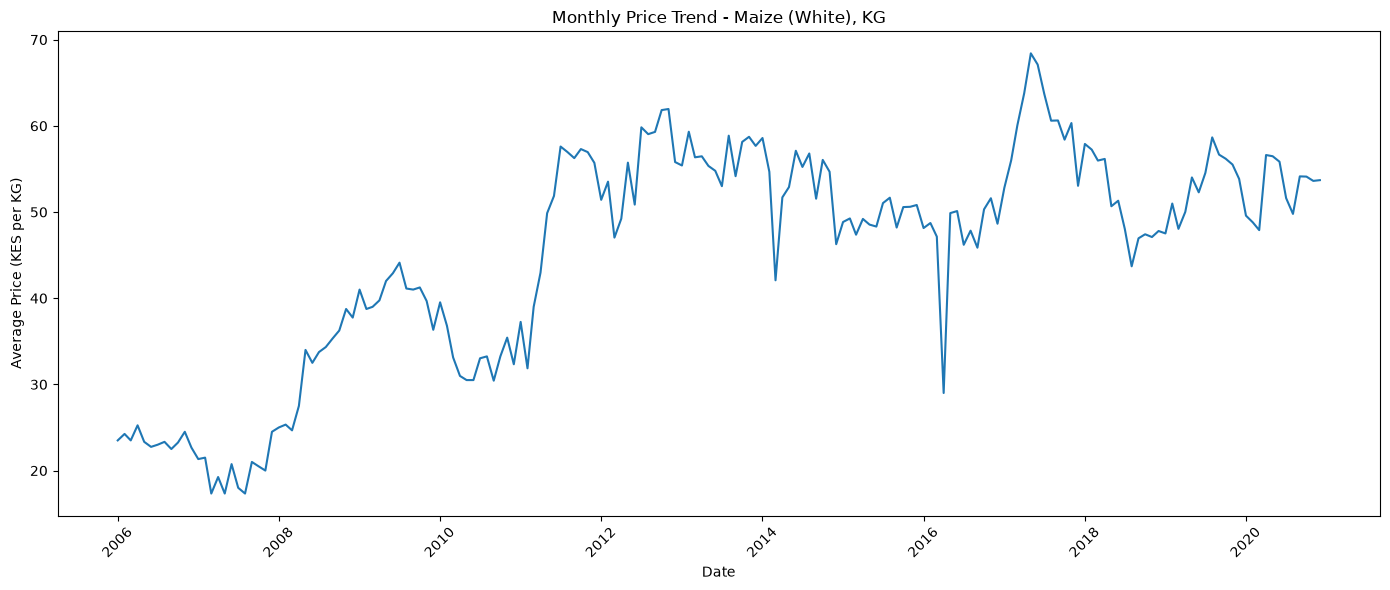

In [58]:
# Filter Maize (white) recorded in KG
maize_kg = df[
    (df['commodity'] == 'Maize (white)') &
    (df['unit'] == 'KG')
].copy()

# Calculate monthly average price
maize_kg_monthly = (
    maize_kg.groupby('date_month')['price']
    .mean()
    .reset_index()
)

# Convert date to datetime
maize_kg_monthly['date_month'] = pd.to_datetime(
    maize_kg_monthly['date_month']
)

# Plot the trend
plt.figure(figsize=(14, 6))

plt.plot(
    maize_kg_monthly['date_month'],
    maize_kg_monthly['price']
)

plt.title('Monthly Price Trend - Maize (White), KG')
plt.xlabel('Date')
plt.ylabel('Average Price (KES per KG)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The price of maize (white) shows a clear long-term upward trend with
considerable fluctuations over time.

Prices were relatively low during 2006–2007, followed by a gradual increase
through the following years. A substantial rise occurred around 2011–2012,
after which prices generally remained at higher levels.

The series also contains several sharp increases and decreases, indicating
periods of price volatility. The highest observed monthly average is around
2017, at approximately KES 68 per KG.

These fluctuations are relevant to the project's forecasting objective because
they indicate that maize prices are not constant over time and may require
models capable of capturing both trends and volatility.

## 19. Maize (White) Price by Region

To make regional comparisons consistent, we focus on Maize (white) observations
recorded in KG only.

This allows us to compare prices across regions using the same measurement unit
and identify geographical differences in maize prices.

In [62]:
# Filter Maize (white) recorded in KG only
maize_kg = df[
    (df['commodity'] == 'Maize (white)') &
    (df['unit'] == 'KG')
].copy()

# Calculate price statistics by region
maize_region_price = (
    maize_kg.groupby('admin1')['price']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)

maize_region_price

,count,mean,median,min,max
admin1,,,,,
North Eastern,176,58.08,64.0,22.0,85.00
Rift Valley,307,55.45,52.0,26.0,100.00
Coast,71,43.70,42.0,33.9,87.90
Eastern,351,35.93,37.0,6.0,62.22


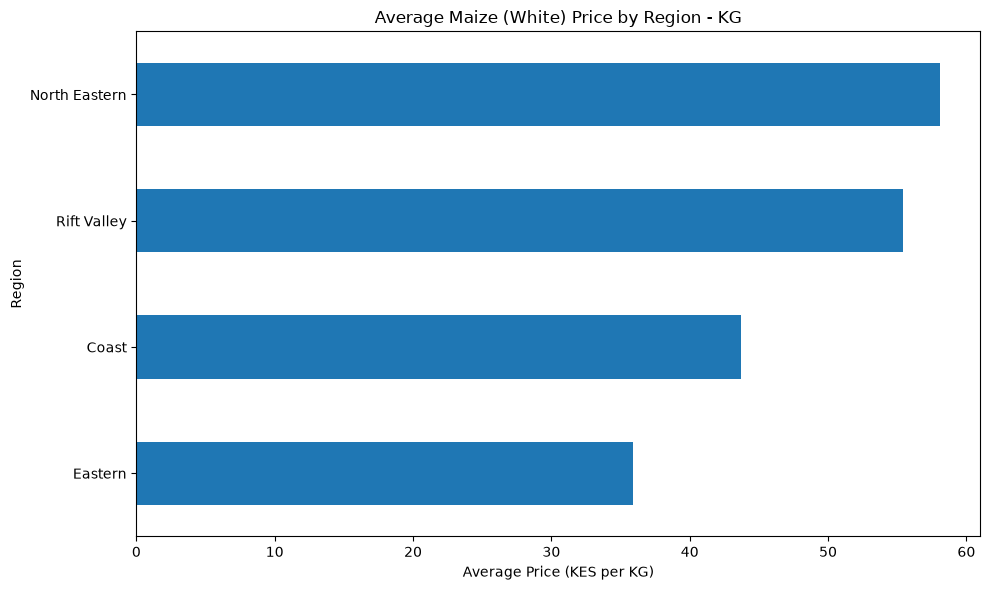

In [63]:
# Plot average Maize (white) price by region
plt.figure(figsize=(10, 6))

maize_region_price['mean'].sort_values().plot(kind='barh')

plt.title('Average Maize (White) Price by Region - KG')
plt.xlabel('Average Price (KES per KG)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

### Observation

The average price of Maize (white) varies considerably across the regions
represented in the KG observations.

North Eastern has the highest average price at approximately KES 58.08 per KG,
followed by Rift Valley at KES 55.45. Coast has an average price of KES 43.70,
while Eastern has the lowest average at approximately KES 35.93 per KG.

The results indicate clear regional differences in maize prices. These
differences may be useful for identifying areas experiencing relatively higher
food prices and for understanding geographical price variation.

## 20. Maize (White) Price by Market

After examining regional differences, we investigate price variation across
individual markets.

This helps identify markets with relatively high or low maize prices and
provides more detailed geographical insight for the food price intelligence
system.

In [64]:
# Calculate average Maize (white) price by market
maize_market_price = (
    maize_kg.groupby('market')['price']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)

# Display the 15 markets with the highest average prices
maize_market_price.head(15)

,count,mean,median,min,max
market,,,,,
Garissa,68,60.94,62.50,50.0,80.00
Lodwar (Turkana),169,60.94,64.58,26.0,100.00
Mandera,108,56.28,64.00,22.0,85.00
Kajiado,70,51.13,49.50,40.0,75.00
Marigat (Baringo),68,46.28,44.50,33.0,81.00
Kilifi,71,43.70,42.00,33.9,87.90
Marsabit,171,41.36,45.00,12.0,62.22
Kitui,180,30.77,33.00,6.0,58.00


In [65]:
# Display the 15 markets with the lowest average prices
maize_market_price.tail(15).sort_values('mean')

,count,mean,median,min,max
market,,,,,
Kitui,180,30.77,33.00,6.0,58.00
Marsabit,171,41.36,45.00,12.0,62.22
Kilifi,71,43.70,42.00,33.9,87.90
Marigat (Baringo),68,46.28,44.50,33.0,81.00
Kajiado,70,51.13,49.50,40.0,75.00
Mandera,108,56.28,64.00,22.0,85.00
Garissa,68,60.94,62.50,50.0,80.00
Lodwar (Turkana),169,60.94,64.58,26.0,100.00


### Observation

The market-level analysis shows substantial variation in the average price of
Maize (white) across markets.

Garissa and Lodwar (Turkana) have the highest average price at approximately
KES 60.94 per KG, followed by Mandera at KES 56.28. Kitui has the lowest
average price among the markets shown, at approximately KES 30.77 per KG.

The difference between markets suggests that maize prices can vary considerably
within Kenya. This market-level variation is important for the project because
the forecasting and intelligence system should account for geographical
differences rather than relying only on national average prices.

## 19. Market-Level Price Comparison

The following visualization compares the average price of Maize (white) across
the markets represented in the KG observations.

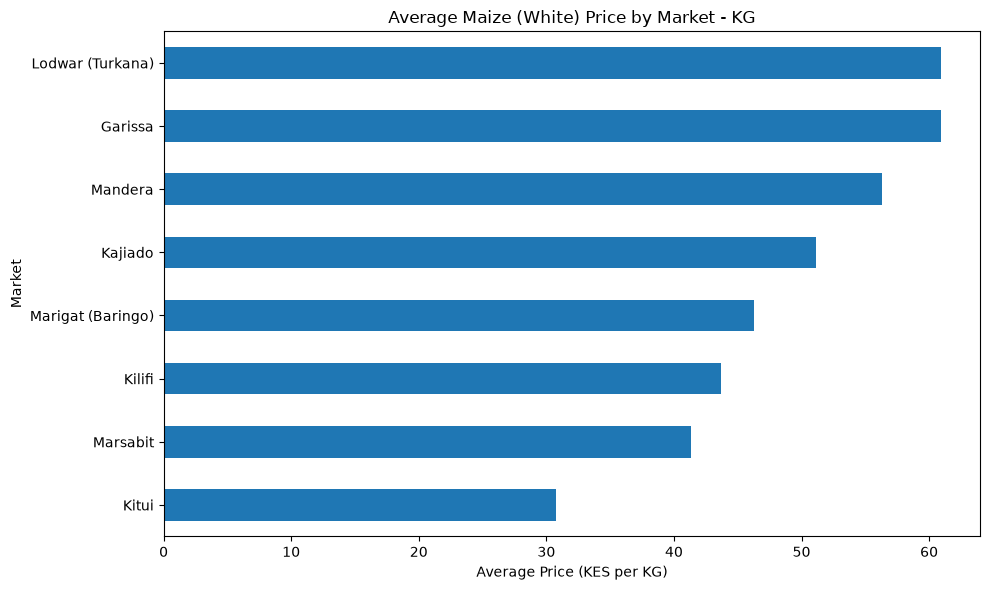

In [66]:
# Plot average Maize (white) price by market
plt.figure(figsize=(10, 6))

maize_market_price['mean'].sort_values().plot(kind='barh')

plt.title('Average Maize (White) Price by Market - KG')
plt.xlabel('Average Price (KES per KG)')
plt.ylabel('Market')
plt.tight_layout()
plt.show()

## 21. Rainfall and Maize (White) Prices

Rainfall is included in the cleaned dataset as a potential factor associated
with food price movements.

We examine the relationship between rainfall and Maize (white) prices to
determine whether changes in rainfall are associated with changes in maize
prices.

In [86]:
# Filter Maize (white) observations recorded in KG
maize_white = df[
    (df['commodity'] == 'Maize (white)') &
    (df['unit'] == 'KG')
].copy()

In [87]:
# Summary statistics for rainfall in Maize (white) observations
maize_white['rainfall_mm'].describe().round(2)

count    905.00
mean      89.20
std       83.36
min        0.09
25%       24.42
50%       56.98
75%      136.58
max      428.30
Name: rainfall_mm, dtype: float64

In [88]:
# Keep observations with rainfall data
maize_rain = maize_white.dropna(
    subset=['rainfall_mm', 'date_month', 'price']
).copy()

# Convert date to datetime
maize_rain['date_month'] = pd.to_datetime(maize_rain['date_month'])

# Calculate monthly averages
maize_rain_monthly = (
    maize_rain
    .groupby('date_month')
    .agg(
        price=('price', 'mean'),
        rainfall_mm=('rainfall_mm', 'mean')
    )
    .reset_index()
)

maize_rain_monthly.head()

,date_month,price,rainfall_mm
0,2006-01-01,23.500000,32.890655
1,2006-02-01,24.250000,36.652530
2,2006-03-01,23.500000,100.084286
3,2006-04-01,25.250000,176.480923
4,2006-05-01,23.333333,102.250238


### . Rainfall and Maize Price Relationship

We examine the relationship between rainfall and the price of Maize (white).

A correlation analysis showed a weak positive relationship between rainfall and maize price.
A scatter plot is used to visually assess whether this relationship is consistent across observations.

In [73]:
# Create a dataset containing only observations with rainfall data
maize_rainfall = maize_white[
    ['date_month', 'price', 'rainfall_mm']
].dropna().copy()

# Check the number of observations available for the analysis
maize_rainfall.shape

(1633, 3)

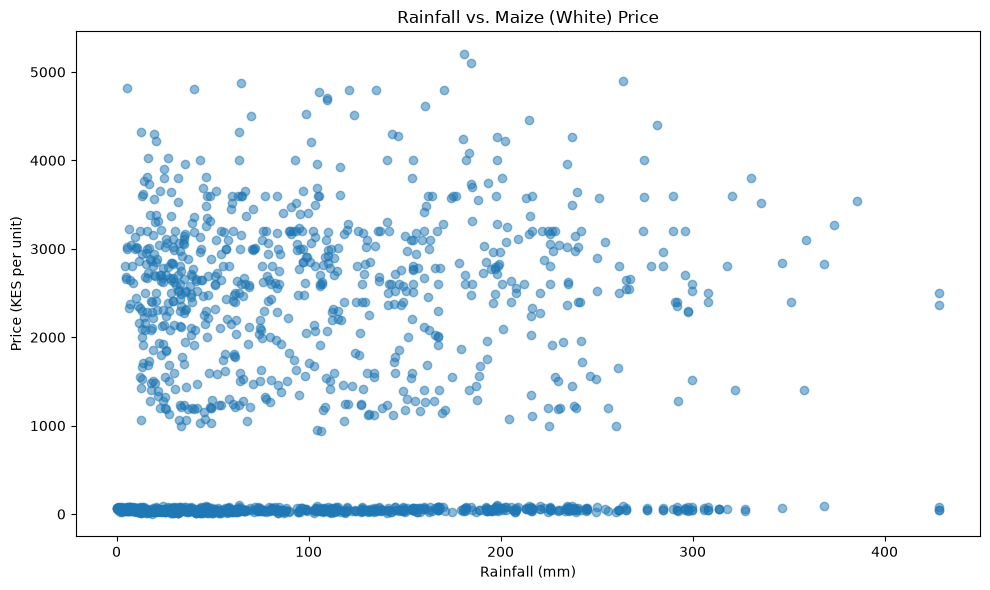

In [74]:
# Create a scatter plot of rainfall against maize price
plt.figure(figsize=(10, 6))

plt.scatter(
    maize_rainfall['rainfall_mm'],
    maize_rainfall['price'],
    alpha=0.5
)

plt.title('Rainfall vs. Maize (White) Price')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Price (KES per unit)')
plt.tight_layout()
plt.show()

In [75]:
# Calculate Pearson correlation between rainfall and maize price
rainfall_price_corr = maize_rainfall[
    ['rainfall_mm', 'price']
].corr().loc['rainfall_mm', 'price']

print(f"Correlation between rainfall and maize price: {rainfall_price_corr:.3f}")

Correlation between rainfall and maize price: 0.127


### Interpretation

The correlation between rainfall and Maize (white) price is approximately **0.147**.

This indicates a **weak positive linear relationship**: higher rainfall is associated with slightly higher maize prices in this dataset.

However, the relationship is weak, so rainfall alone does not explain much of the variation in maize prices. Other factors such as region, market conditions, seasonality, supply, demand, and commodity characteristics may also influence prices.

Correlation does not imply causation.

## 22. Monthly Seasonality of Maize (White) Prices

We examine the average price of Maize (white) across calendar months.

This helps identify recurring seasonal patterns in maize prices that may be
useful when developing forecasting models.

In [76]:
# Create a copy of the Maize (white), KG dataset
maize_seasonal = maize_kg.copy()

# Convert date_month to datetime
maize_seasonal['date_month'] = pd.to_datetime(
    maize_seasonal['date_month']
)

# Extract calendar month
maize_seasonal['month'] = maize_seasonal['date_month'].dt.month

# Calculate average price for each calendar month
monthly_seasonality = (
    maize_seasonal
    .groupby('month')['price']
    .mean()
    .round(2)
)

monthly_seasonality

month
1     45.95
2     46.09
3     44.54
4     46.28
5     49.08
6     48.02
7     48.32
8     48.55
9     47.64
10    48.55
11    48.84
12    47.12
Name: price, dtype: float64

### Observation

The monthly analysis shows some seasonal variation in Maize (white) prices.

The average price is lowest in March at approximately KES 44.54 per KG and
highest in May at approximately KES 49.08 per KG. Prices generally remain
within a relatively narrow range throughout the year, suggesting that
seasonality exists but does not fully explain maize price movements.

This seasonal pattern can be included as a useful feature when developing
forecasting models.

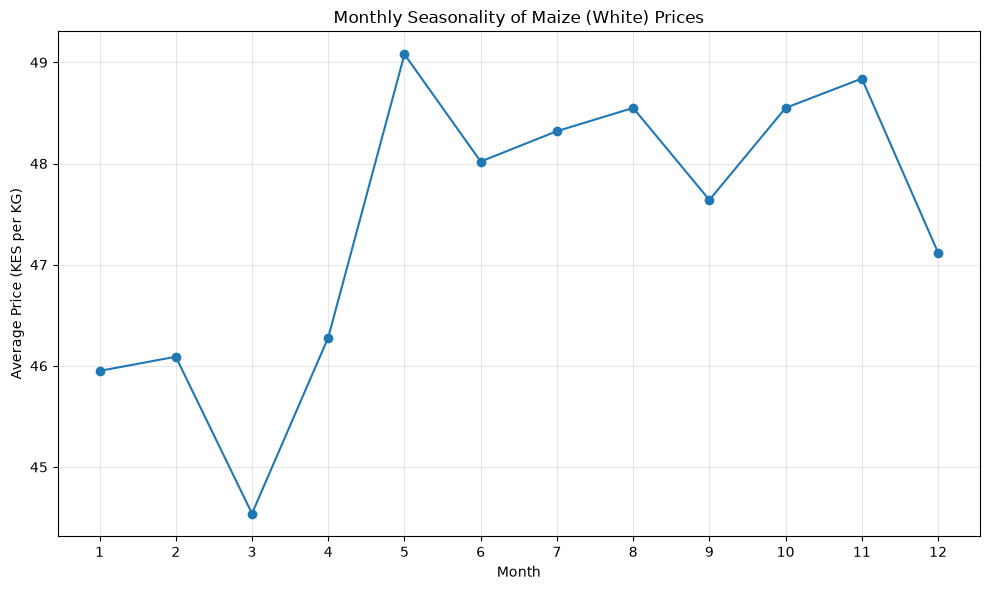

In [77]:
# Plot average maize price by calendar month
plt.figure(figsize=(10, 6))

monthly_seasonality.plot(kind='line', marker='o')

plt.title('Monthly Seasonality of Maize (White) Prices')
plt.xlabel('Month')
plt.ylabel('Average Price (KES per KG)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation

The monthly analysis shows that Maize (white) prices vary across the calendar
year, indicating the presence of seasonal price patterns.

Some months record relatively higher average prices, while others record lower
average prices. These recurring patterns may provide useful information for
forecasting future maize prices.

However, seasonality alone may not explain price movements, so other factors
such as rainfall, location, market conditions, and supply should also be
considered.

## 23. Annual Average Maize (White) Price Trend

We examine the average annual price of Maize (white) to identify
long-term price movements and years with unusually high or low prices.

This provides a broader view of price trends before developing
forecasting models.

In [78]:
# Create a copy of the Maize (white), KG dataset
maize_annual = maize_kg.copy()

# Convert date_month to datetime
maize_annual['date_month'] = pd.to_datetime(
    maize_annual['date_month']
)

# Extract year
maize_annual['year'] = maize_annual['date_month'].dt.year

# Calculate annual average price
annual_price = (
    maize_annual
    .groupby('year')['price']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .round(2)
)

annual_price

,count,mean,median,min,max
year,,,,,
2006,44,23.52,22.00,17.0,31.0
2007,43,20.09,18.00,8.0,31.0
2008,42,32.43,31.50,13.0,55.0
2009,44,40.65,42.00,30.0,52.0
2010,45,33.41,34.00,6.0,49.6
2011,38,48.87,45.80,17.0,74.8
2012,43,56.00,51.70,37.0,80.0
2013,41,56.71,53.40,30.0,87.8
2014,39,53.64,50.96,30.0,84.0


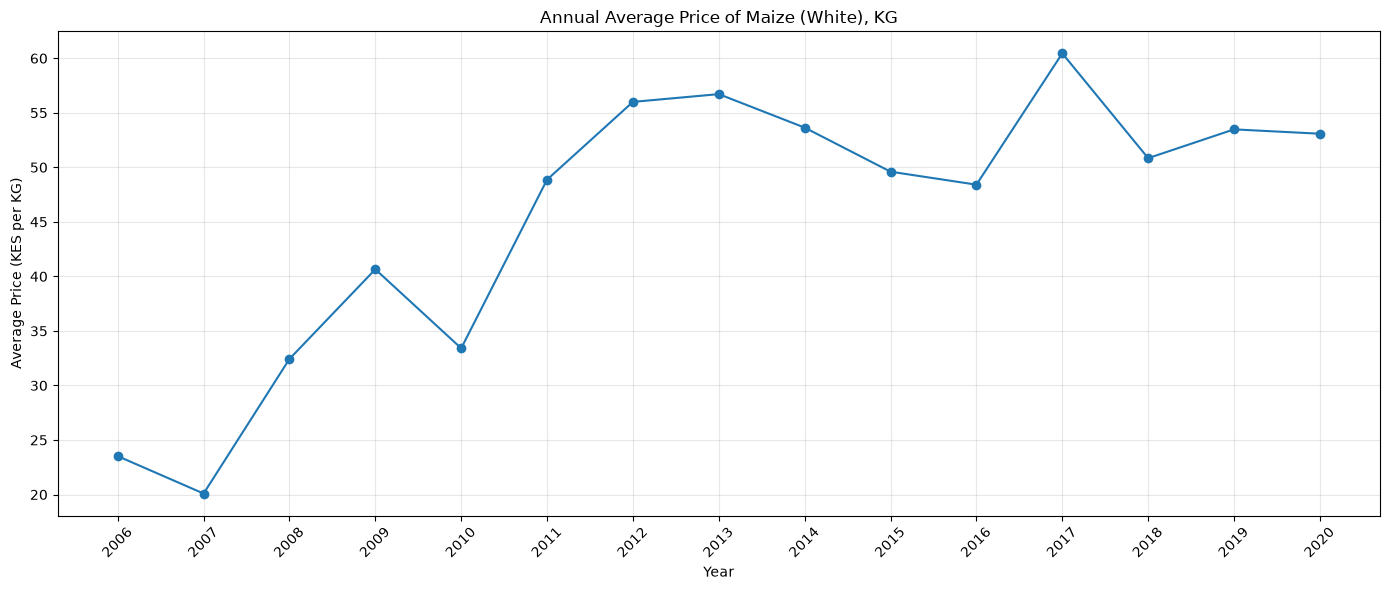

In [80]:
# Plot annual average maize price
plt.figure(figsize=(14, 6))

plt.plot(
    annual_price.index,
    annual_price['mean'],
    marker='o'
)

plt.title('Annual Average Price of Maize (White), KG')
plt.xlabel('Year')
plt.ylabel('Average Price (KES per KG)')
plt.xticks(annual_price.index, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
# Year with the highest average price
highest_year = annual_price['mean'].idxmax()
highest_price = annual_price.loc[highest_year, 'mean']

# Year with the lowest average price
lowest_year = annual_price['mean'].idxmin()
lowest_price = annual_price.loc[lowest_year, 'mean']

print(f"Highest average price: {highest_year} - KES {highest_price:.2f}/KG")
print(f"Lowest average price: {lowest_year} - KES {lowest_price:.2f}/KG")

Highest average price: 2017 - KES 60.45/KG
Lowest average price: 2007 - KES 20.09/KG


## Price Volatility

We examine month-to-month changes in Maize (white) prices to identify periods
of unusually high price increases or decreases.

This is relevant to the project because detecting abnormal price movements
can help identify potential food-price shocks and periods that may require
closer market monitoring.

In [82]:
# Sort the monthly maize price data by date
maize_kg_monthly = maize_kg_monthly.sort_values('date_month').copy()

# Calculate month-to-month percentage change
maize_kg_monthly['price_change_pct'] = (
    maize_kg_monthly['price']
    .pct_change() * 100
)

# Display the largest price increases and decreases
maize_kg_monthly.sort_values(
    'price_change_pct',
    ascending=False
).head(10)

,date_month,price,price_change_pct
124,2016-05-01,49.875000,71.982759
28,2008-05-01,34.000000,23.636364
99,2014-04-01,51.700000,22.861217
23,2007-12-01,24.500000,22.500000
62,2011-03-01,39.000000,22.384937
20,2007-09-01,21.000000,21.153846
17,2007-06-01,20.750000,19.711538
171,2020-04-01,56.614286,18.192663
78,2012-07-01,59.830000,17.628940
64,2011-05-01,49.866667,16.058960


## 24.Price Volatility and Monthly Price Changes

We examine month-to-month percentage changes in Maize (white) prices to identify
periods of unusually large price movements.

This helps assess price volatility and provides a better understanding of how
stable or variable maize prices are over time.

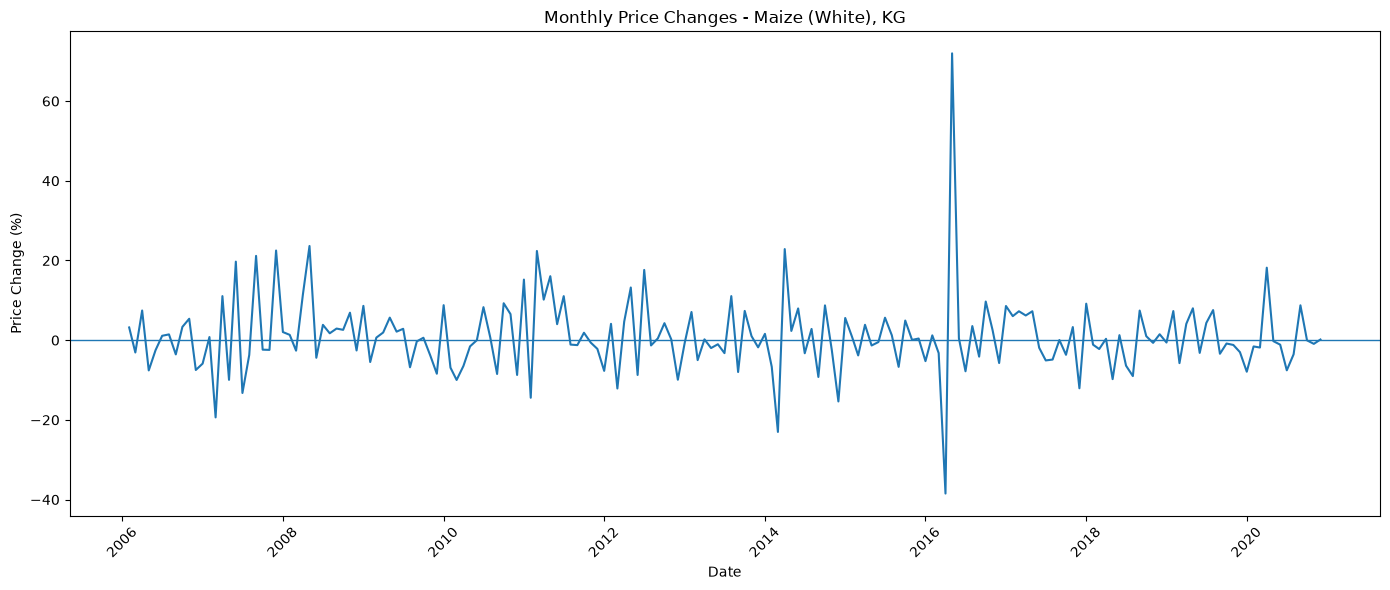

In [83]:
# Plot monthly price changes
plt.figure(figsize=(14, 6))

plt.plot(
    maize_kg_monthly['date_month'],
    maize_kg_monthly['price_change_pct']
)

plt.axhline(0, linewidth=1)

plt.title('Monthly Price Changes - Maize (White), KG')
plt.xlabel('Date')
plt.ylabel('Price Change (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 25. EDA Summary and Key Findings

The exploratory data analysis provided an overview of the structure, quality,
distribution, and patterns in the Kenya food price dataset.

The main findings are:

- The dataset contains food price observations covering more than 20 years,
  from January 2006 to August 2026.
- The dataset contains 225 markets, 7 regions, 51 commodities, and 8 categories.
- There are no completely duplicated records.
- Missing values are present in `rainfall_mm`, while the other main variables
  are complete.
- The dataset contains different measurement units, including KG, 90 KG,
  50 KG, litres, grams, and individual units. Therefore, prices should be
  compared within consistent commodity and unit groups.
- Retail prices account for approximately two-thirds of the observations,
  while wholesale prices account for approximately one-third.
- Food prices are strongly right-skewed, with several high recorded values.
  These extreme values are partly explained by differences in commodities,
  measurement units, and price types.
- The composition of measurement units changes considerably over time,
  particularly from 2021 onwards. This explains why aggregate price trends
  should be interpreted carefully.
- Maize (white) has substantial historical coverage and was examined in
  greater detail.
- Maize (white) prices show considerable variation over time, including
  periods of rapid increases and decreases.
- Maize prices differ across regions and markets, with North Eastern and
  Rift Valley generally recording higher average prices than Eastern in the
  KG observations examined.
- Monthly analysis shows some seasonal variation in maize prices, although
  the differences between months are relatively moderate.
- Month-to-month price changes reveal periods of substantial volatility,
  including an increase of approximately 72% in May 2016.
- Rainfall has a weak positive correlation with Maize (white) prices
  (approximately 0.147), indicating that rainfall alone does not explain
  much of the observed price variation.

Overall, the EDA shows that food prices vary across time, location,
commodity, measurement unit, and price type. These characteristics are
important considerations when interpreting the dataset and its price patterns.